### Pipeline

This script takes a single 2D TIFF frame, extracts a region of interest (ROI), removes a smooth background, and then uses juwavelet to identify and visualize the main gravity‐wave packets.

Pipeline:

1. Load the full TIFF as a 2D float32 array and compute the global mean and sigma.
2. Build a full-frame preview:
   - Mask pixels outside mean ± (SIGMA_FACTOR · σ).
   - Display the masked image with a fixed color range and draw the ROI rectangle.
3. Extract the ROI using X_SLICE and Y_SLICE.
4. Apply the same global mean ± σ range filter inside the ROI (optional), and fill “invalid” pixels (outside the range) so the ROI remains a full rectangle for the CWT.
5. Remove a smooth background from the ROI:
   - Fit and subtract a 2D plane (optional).
   - Extract and subtract the first Fourier components in x and y.
   - Define the “remaining” field = original − background.
6. Apply a Hanning edge taper to the remaining field (optional), then optionally despike it using a local median / MAD filter (DESPIKE_SIZE, DESPIKE_K).
7. Make a 4-panel figure showing:
   - Original (median-subtracted).
   - Background (plane + first Fourier).
   - Remaining = original − background.
   - Remaining with edge taper (and spikes removed).
8. Preprocess the tapered, despiked field for CWT:
   - Median-center and standardize (optional).
   - Apply a small Gaussian blur (optional).
9. Run 2D continuous wavelet transform with juwavelet.decompose2d using the specified S0, DJ, JS, JT, DX, DY, ASPECT.
10. Identify wave clusters in wavelet space with utils.identify_cluster2d (CLUSTER_MIN_AMP, CLUSTER_THR).
11. Plot:
    - A decomposition overview (utils.plot_decomposition2d).
    - A FOV wavelet spectrum (orientation vs wavelength) via plot_utils.plot_fov_wavelet_spectrum.
12. For the 9 strongest clusters:
    - Reconstruct each cluster back into physical space.
    - Plot 9 standalone cluster fields (median-centered).
    - Plot 9 overlays: each cluster on top of the tapered, despiked background field.

Outputs: one full-frame preview, one 4-panel background figure, a CWT summary figure, a polar FOV spectrum, 9 standalone cluster plots, and 9 cluster-on-background overlays.


[Full] mean: 7913.33
[Full] sigma: 3217.16
[Full] Clip range: [6304.75, 9521.91] = mean ± 0.50·sigma
[Full] Count: 81920
[Full] Min/max after clip: 6304.75 / 9521.91
[Full] Percentiles 5/50/95 (clipped): 6835.00 / 7942.00 / 8833.00


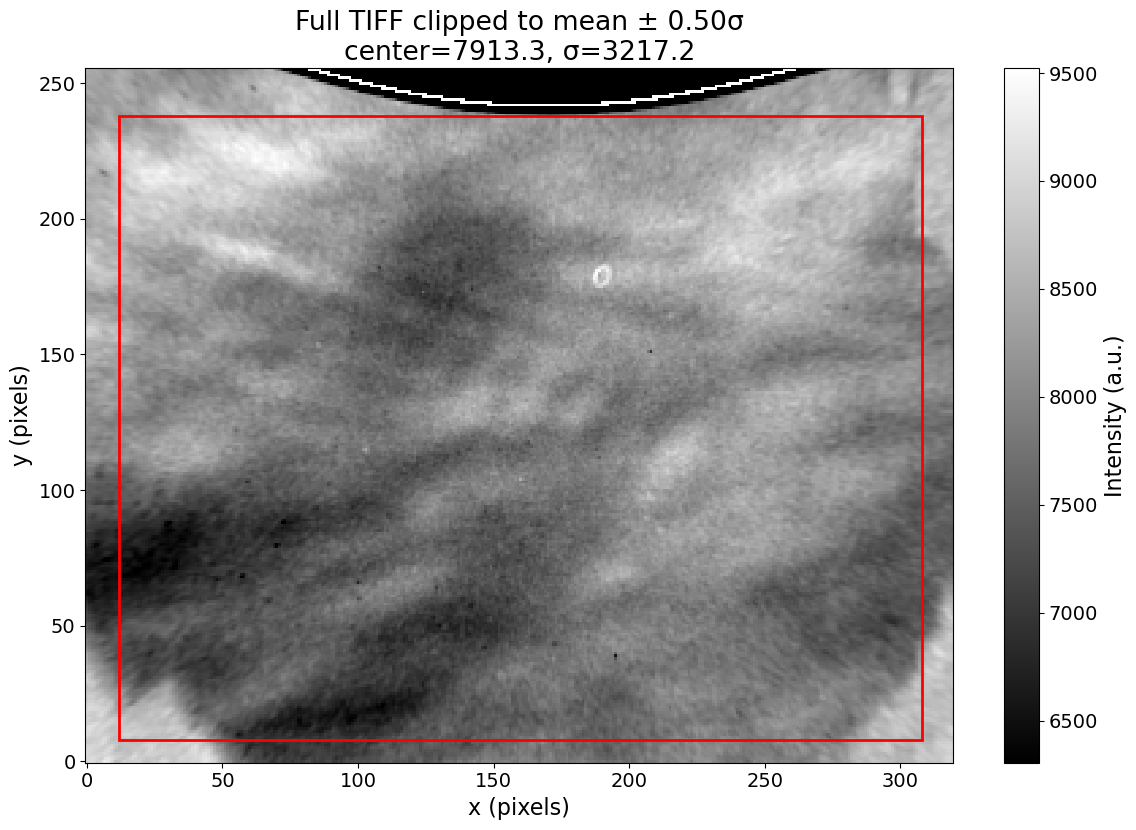

[ROI] shape: (230, 296)
[ROI] Count: 68080
[ROI] Min/max after clip: 6304.75 / 9521.91
[ROI] Percentiles 5/50/95 (clipped): 7010.00 / 7920.00 / 8814.00


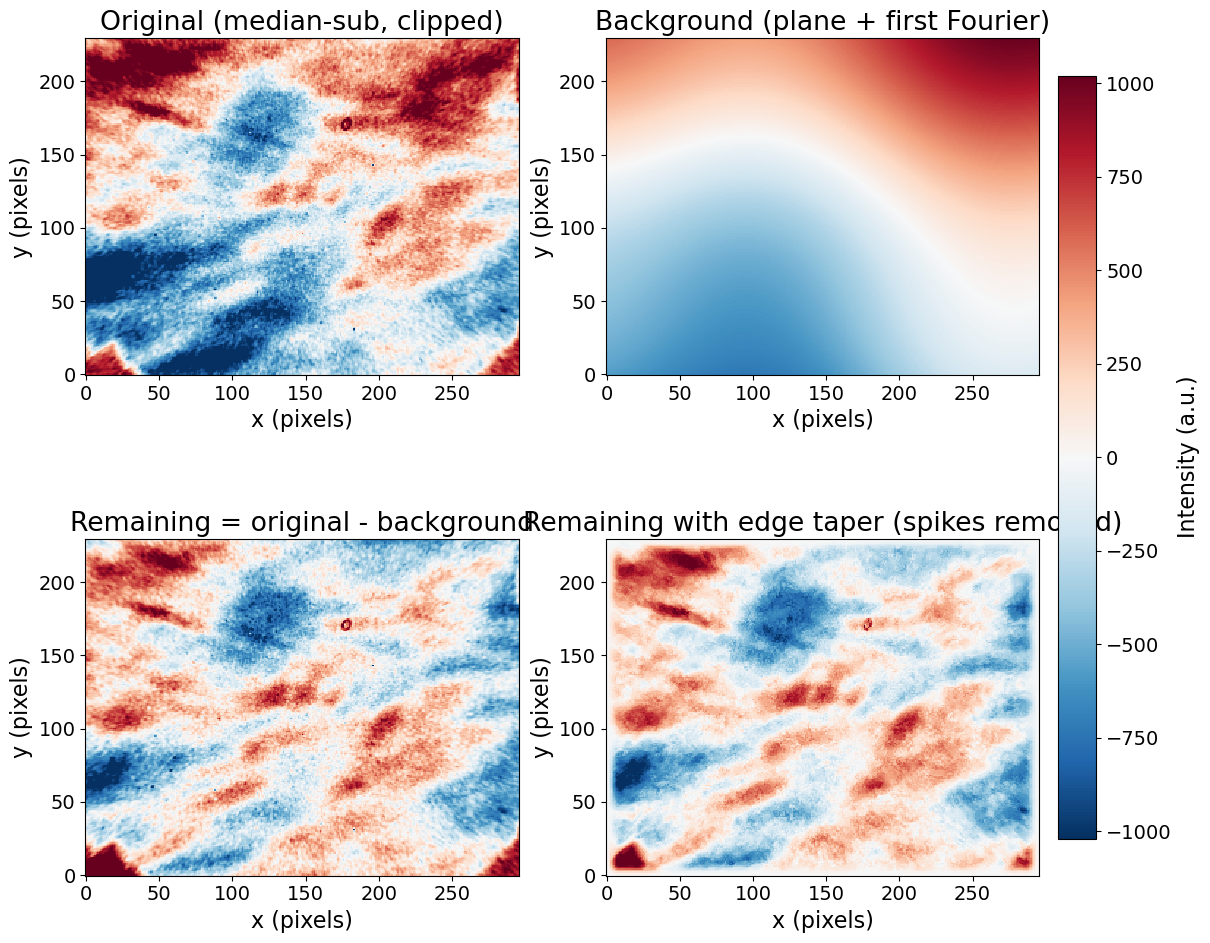

C:\Users\domin\juwavelet\juwavelet\transform.py:324: RuntimeWarning: divide by zero encountered in divide
  wys = periods[:, np.newaxis] / (aspect * np.sin(thetas[np.newaxis, :]))
C:\Users\domin\juwavelet\juwavelet\transform.py:367: RuntimeWarning: divide by zero encountered in divide
  "wavelength_y": periods[:, np.newaxis] / (aspect * np.sin(thetas[np.newaxis, :])),


------------
cluster= 0
amplitude= 0.3965708109216384 idx= (np.int64(15), np.int64(7), np.int64(99), np.int64(164))
selected elements: 117722
------------
cluster= 1
amplitude= 0.3963176971882907 idx= (np.int64(20), np.int64(7), np.int64(237), np.int64(111))
selected elements: 124481
------------
cluster= 2
amplitude= 0.3959749323833172 idx= (np.int64(12), np.int64(11), np.int64(53), np.int64(46))
selected elements: 47038
------------
cluster= 3
amplitude= 0.3765293935415222 idx= (np.int64(27), np.int64(7), np.int64(66), np.int64(148))
selected elements: 1123743
------------
cluster= 4
amplitude= 0.3709046165220733 idx= (np.int64(30), np.int64(4), np.int64(122), np.int64(145))
selected elements: 194125
------------
cluster= 5
amplitude= 0.36735487769348457 idx= (np.int64(19), np.int64(8), np.int64(144), np.int64(131))
selected elements: 19212
------------
cluster= 6
amplitude= 0.35701882029123777 idx= (np.int64(19), np.int64(8), np.int64(29), np.int64(210))
selected elements: 67154
---

C:\Users\domin\juwavelet\juwavelet\utils.py:62: RuntimeWarning: divide by zero encountered in scalar divide
  hl = 1. / np.sin(theta[sel_t[j]])
100%|██████████████████████████████████████████████████████████████████████████████████| 13/13 [00:00<00:00, 67.31it/s]
C:\Users\domin\juwavelet\juwavelet\utils.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


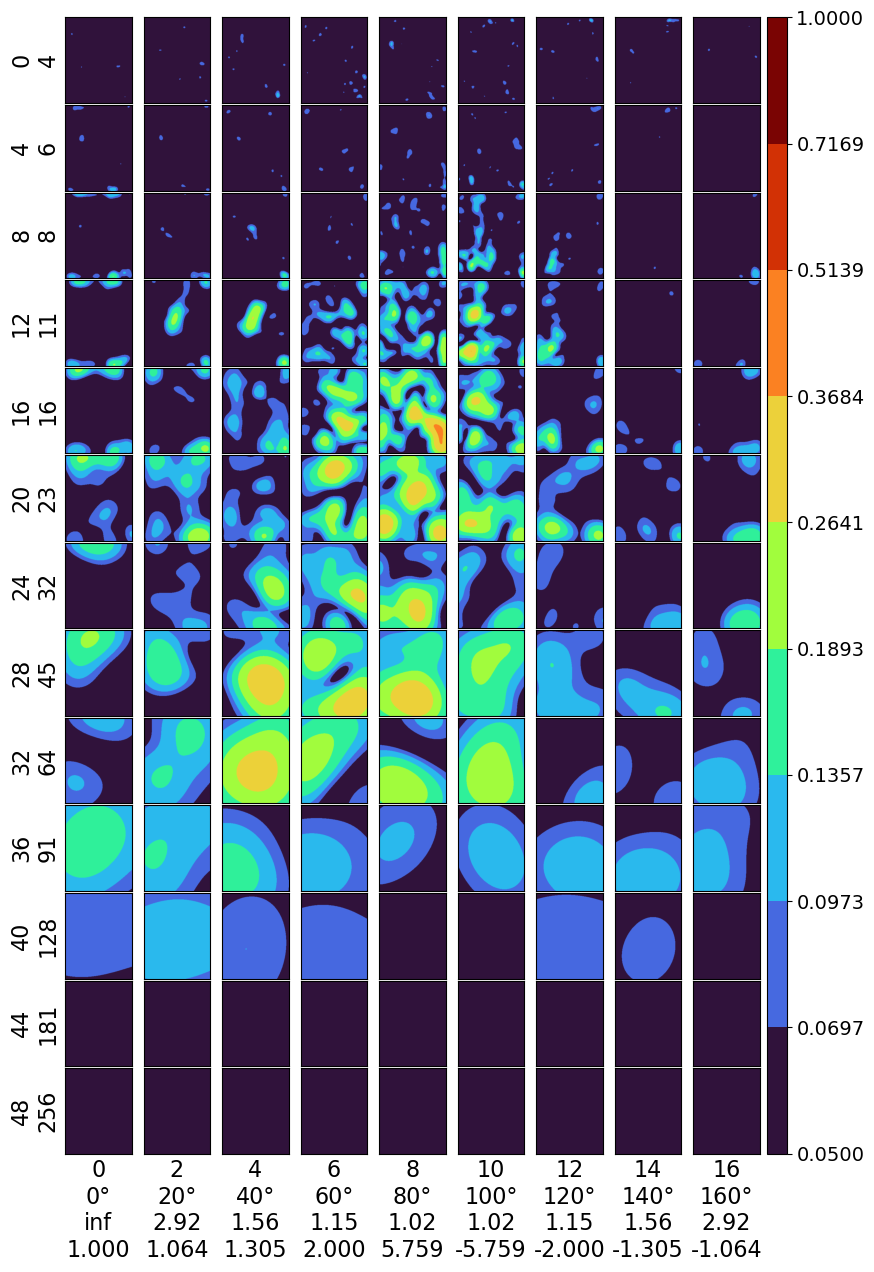

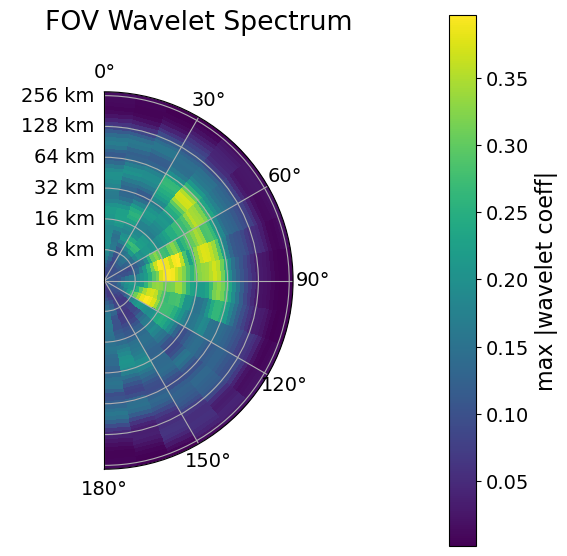

[Clusters-only] Cluster 0: amp=0.397, lamx=42.90, lamy=15.61, lam=14.67
[Clusters-only] Cluster 1: amp=0.396, lamx=66.16, lamy=24.08, lam=22.63
[Clusters-only] Cluster 2: amp=0.396, lamx=-33.08, lamy=12.04, lam=11.31
[Clusters-only] Cluster 3: amp=0.377, lamx=121.33, lamy=44.16, lam=41.50
[Clusters-only] Cluster 4: amp=0.371, lamx=70.25, lamy=83.72, lam=53.82
[Clusters-only] Cluster 5: amp=0.367, lamx=119.49, lamy=21.07, lam=20.75
[Clusters-only] Cluster 6: amp=0.357, lamx=119.49, lamy=21.07, lam=20.75
[Clusters-only] Cluster 7: amp=0.349, lamx=119.49, lamy=21.07, lam=20.75
[Clusters-only] Cluster 8: amp=0.343, lamx=55.63, lamy=20.25, lam=19.03


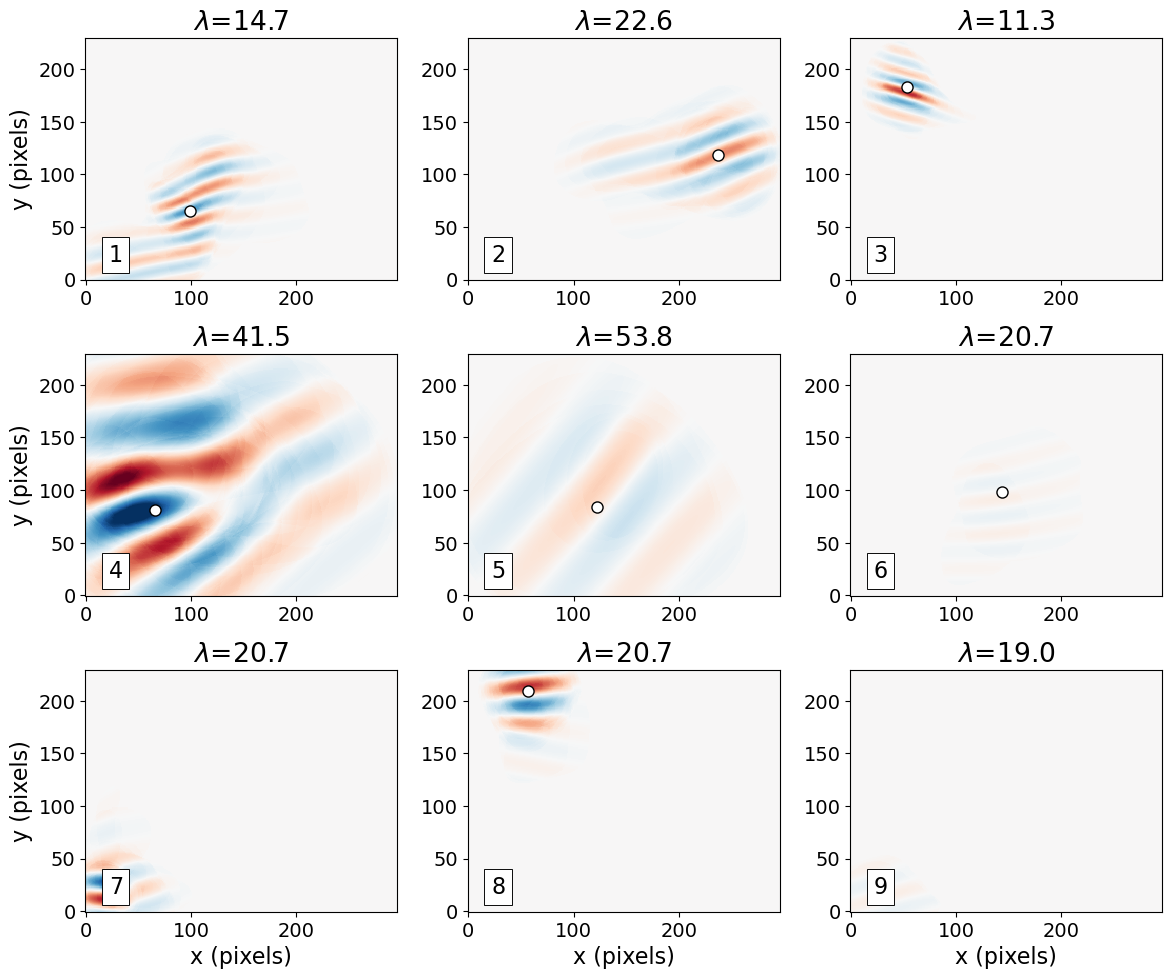

[Overlay] Cluster 0: amp=0.397, lamx=42.90, lamy=15.61, lam=14.67
[Overlay] Cluster 1: amp=0.396, lamx=66.16, lamy=24.08, lam=22.63
[Overlay] Cluster 2: amp=0.396, lamx=-33.08, lamy=12.04, lam=11.31
[Overlay] Cluster 3: amp=0.377, lamx=121.33, lamy=44.16, lam=41.50
[Overlay] Cluster 4: amp=0.371, lamx=70.25, lamy=83.72, lam=53.82
[Overlay] Cluster 5: amp=0.367, lamx=119.49, lamy=21.07, lam=20.75
[Overlay] Cluster 6: amp=0.357, lamx=119.49, lamy=21.07, lam=20.75
[Overlay] Cluster 7: amp=0.349, lamx=119.49, lamy=21.07, lam=20.75
[Overlay] Cluster 8: amp=0.343, lamx=55.63, lamy=20.25, lam=19.03


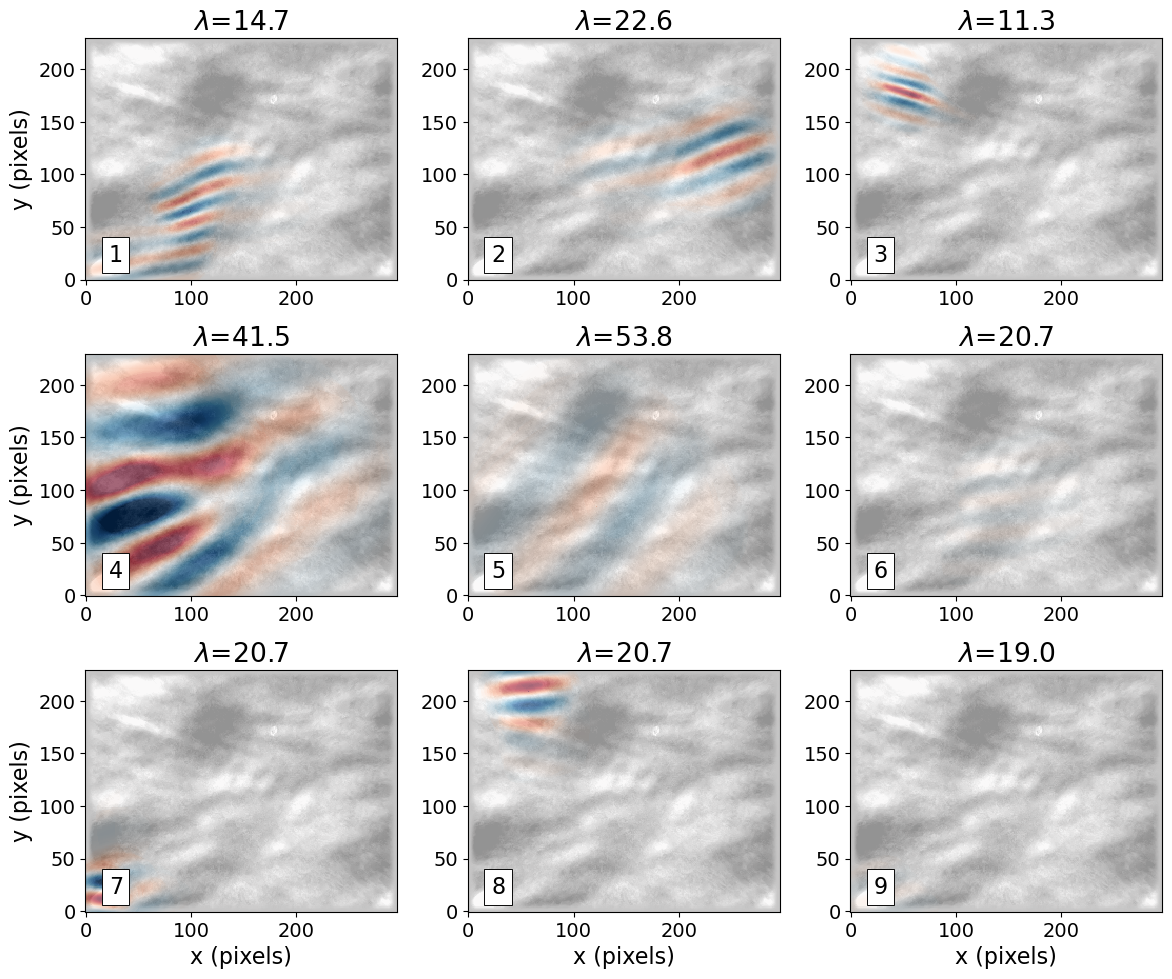

In [3]:
# Full TIFF -> ROI -> background removal -> wavelet clusters
#
# Produces:
#   1) Full TIFF preview (mean ± 0.5 sigma) with ROI rectangle
#   2) 4-panel background figure:
#        - original (median-sub)
#        - background (plane + first Fourier)
#        - remaining
#        - remaining with edge taper, spikes removed (if enabled)
#   3) Wavelet decomposition summary (utils.plot_decomposition2d)
#   4) FOV wavelet spectrum (orientation vs wavelength)
#   5) 9 standalone wavelet clusters (reconstructed fields)
#   6) 9 overlay clusters on top of the tapered remaining field (spikes removed)

from __future__ import annotations
from typing import Tuple, Optional

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import tifffile as tiff

from scipy.ndimage import median_filter
from juwavelet import transform, utils, plot_utils

# --------------------------
# User params
# --------------------------
TIFF_PATH = r"C:\Users\domin\juwavelet\examples\Waves For Anh\Sep14th527\BandOH_caun0121.tif"

# ROI (pixel slices) for analysis. Set to None to use full image.
X_SLICE: Optional[slice] = slice(12, 308)
Y_SLICE: Optional[slice] = slice(18, 248)

# Single sigma factor: mean ± 0.5σ (computed once on full image)
SIGMA_FACTOR = 0.5

# Preprocessing / background
REMOVE_TREND = True         # include 2D plane in "background"
STANDARDIZE = True          # z-score like scaling before CWT
GAUSS_BLUR_SIGMA = 0        # 0 disables, else e.g. 0.8

# Edge taper on remaining field (before CWT)
APPLY_TAPER = True
TAPER_EDGE_PIXELS = 10      # width of tapered region near each edge (pixels)

# Despike options (applied after tapering, before CWT)
APPLY_DESPIKE = True
DESPIKE_SIZE = 5            # median window size (odd integer)
DESPIKE_K = 2.0             # threshold in local "sigma" units

# Wavelet params
S0 = 4
DJ = 1/8
JS = 50
JT = 18
ASPECT = 1

# Pixel spacing (km/pixel) for CWT (wavelengths will be in km)
DX = 0.623
DY = 0.623

# Cluster identification parameters
CLUSTER_MIN_AMP = 0.25      # min_amp for identify_cluster2d
CLUSTER_THR = 0.2           # thr for identify_cluster2d

# --------------------------
# Plot style
# --------------------------
matplotlib.rcParams.update({
    "axes.labelsize": 16,
    "font.size": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "figure.figsize": [2 * 6.94, 2 * 4.29],
})


# --------------------------
# Helpers
# --------------------------
def load_tiff(
    path: str,
) -> np.ndarray:
    """Load single-frame 2D TIFF as float32 array."""
    img = tiff.imread(path)
    if img.ndim == 3 and img.shape[-1] == 1:
        img = img[..., 0]
    if img.ndim != 2:
        raise ValueError(f"Expected single-frame 2D TIFF; got shape {img.shape}")
    Z = np.asarray(img, dtype=np.float32)
    med = float(np.median(Z))
    Z = np.nan_to_num(Z, nan=med, posinf=med, neginf=med).astype(np.float32, copy=False)
    return Z


def fit_plane(Z: np.ndarray) -> np.ndarray:
    """
    Fit a 2D plane ax + by + c to Z (least squares) and return the plane.
    """
    ny, nx = Z.shape
    yy, xx = np.mgrid[0:ny, 0:nx]
    G = np.stack([xx.ravel(), yy.ravel(), np.ones(nx * ny)], axis=1)
    coeff, *_ = np.linalg.lstsq(G, Z.ravel(), rcond=None)
    plane = (coeff[0] * xx + coeff[1] * yy + coeff[2])
    return plane


def extract_first_fourier_bg(Z: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """
    From a 2D field Z, keep only the first Fourier components in x and y:

      - fundamental in x: kx = ±1, ky = 0
      - fundamental in y: ky = ±1, kx = 0

    Returns (background_from_fft, residual).
    """
    ny, nx = Z.shape
    F = np.fft.fft2(Z)
    F_bg = np.zeros_like(F, dtype=complex)

    # fundamental in x (along columns, ky = 0)
    if nx > 1:
        F_bg[0, 1] = F[0, 1]
        F_bg[0, -1] = F[0, -1]

    # fundamental in y (along rows, kx = 0)
    if ny > 1:
        F_bg[1, 0] = F[1, 0]
        F_bg[-1, 0] = F[-1, 0]

    bg = np.fft.ifft2(F_bg).real
    resid = Z - bg
    return bg, resid


def maybe_blur(Z: np.ndarray, sigma: float) -> np.ndarray:
    if sigma <= 0:
        return Z
    try:
        from scipy.ndimage import gaussian_filter
    except Exception:
        return Z
    return gaussian_filter(Z, sigma=float(sigma))


def _fmt(v: float) -> str:
    if not np.isfinite(v):
        return "∞"
    v = float(v)
    if abs(v) >= 1000 or abs(v) < 0.1:
        return f"{v:.2e}"
    elif abs(v) >= 100:
        return f"{v:.0f}"
    else:
        return f"{v:.1f}"


def despike_local_sigma(
    Z: np.ndarray,
    size: int = 3,
    k: float = 5.0,
) -> np.ndarray:
    """
    Replace pixels that deviate too much from a local median.

    Parameters
    ----------
    Z : 2D array
    size : int
        Window size for local median (3, 5, ...)
    k : float
        Threshold in units of local MAD (~sigma). Larger = more tolerant.

    Returns
    -------
    2D array, same shape as Z
    """
    Z = np.asarray(Z, float)
    med = median_filter(Z, size=size)
    mad = median_filter(np.abs(Z - med), size=size)
    mad = np.where(mad == 0, np.nan, mad)

    mask_spike = np.abs(Z - med) > k * mad

    Z_clean = Z.copy()
    Z_clean[mask_spike] = med[mask_spike]
    return Z_clean


# --------------------------
# Edge taper (Hanning near boundaries)
# --------------------------
def _hanning_edge_1d(n: int, edge: int) -> np.ndarray:
    """
    1D window that is ~0 at the very edges, ramps to 1 over `edge` pixels,
    and equals 1 in the interior. Hanning-like cosine ramp.
    """
    w = np.ones(n, dtype=float)
    if edge <= 0:
        return w
    edge = min(edge, n // 2)
    ramp = 0.5 * (1.0 - np.cos(np.linspace(0, np.pi, edge, endpoint=True)))
    w[:edge] = ramp
    w[-edge:] = ramp[::-1]
    return w


def apply_edge_hanning_taper(Z: np.ndarray, edge: int) -> np.ndarray:
    """
    Apply a separable 2D Hanning-like taper only near the edges:
      interior stays ~1
      transitions smoothly to 0 at the borders over `edge` pixels.
    """
    ny, nx = Z.shape
    if edge <= 0:
        return Z
    wx = _hanning_edge_1d(nx, edge)
    wy = _hanning_edge_1d(ny, edge)
    W = np.outer(wy, wx)   # shape (ny, nx)
    return Z * W


# --------------------------
# Main pipeline
# --------------------------
def run_pipeline():
    # 1) Load full TIFF
    full = load_tiff(TIFF_PATH)
    ny_full, nx_full = full.shape
    x_full = np.arange(nx_full, dtype=float)
    y_full = np.arange(ny_full, dtype=float)

    # 2) Compute mean/std once on the full image, use ±0.5σ everywhere
    sample_full = full.ravel().astype(float)
    center = float(np.mean(sample_full))
    sigma = float(np.std(sample_full))
    k = SIGMA_FACTOR
    lo = center - k * sigma
    hi = center + k * sigma

    print(f"[Full] mean: {center:.2f}")
    print(f"[Full] sigma: {sigma:.2f}")
    print(f"[Full] Clip range: [{lo:.2f}, {hi:.2f}] = mean ± {k:.2f}·sigma")

    # 3) Full-image preview with that same range, and ROI rectangle
    preview = full.astype(float)
    disp_prev = np.clip(preview, lo, hi)

    vals_full = disp_prev.ravel()
    if vals_full.size > 0:
        print(f"[Full] Count: {vals_full.size}")
        print(f"[Full] Min/max after clip: {np.nanmin(vals_full):.2f} / {np.nanmax(vals_full):.2f}")
        p5f, p50f, p95f = np.nanpercentile(vals_full, [5, 50, 95])
        print(f"[Full] Percentiles 5/50/95 (clipped): {p5f:.2f} / {p50f:.2f} / {p95f:.2f}")
    else:
        print("[Full] Warning: no pixels?")

    # Flip y for display
    y_full_flip = y_full[::-1]

    fig_prev, ax_prev = plt.subplots()
    im_prev = ax_prev.pcolormesh(
        x_full,
        y_full_flip,
        disp_prev,
        shading="auto",
        cmap="gray",
        vmin=lo,
        vmax=hi,
    )
    cb_prev = fig_prev.colorbar(im_prev, ax=ax_prev, fraction=0.046, pad=0.04)
    cb_prev.set_label("Intensity (a.u.)")
    ax_prev.set_xlabel("x (pixels)")
    ax_prev.set_ylabel("y (pixels)")
    ax_prev.set_title(f"Full TIFF clipped to mean ± {k:.2f}σ\ncenter={center:.1f}, σ={sigma:.1f}")
    ax_prev.set_aspect("equal", adjustable="box")

    # ROI rectangle in full-image coordinates
    ysl_full = Y_SLICE if Y_SLICE is not None else slice(0, ny_full)
    xsl_full = X_SLICE if X_SLICE is not None else slice(0, nx_full)

    x0 = 0 if xsl_full.start is None else xsl_full.start
    x1 = nx_full if xsl_full.stop is None else xsl_full.stop
    y0 = 0 if ysl_full.start is None else ysl_full.start
    y1 = ny_full if ysl_full.stop is None else ysl_full.stop

    # Map to flipped-y display coords: [y0, y1) -> [ny_full - y1, ny_full - y0)
    y0_disp = ny_full - y1
    y1_disp = ny_full - y0

    rect = patches.Rectangle(
        (x0, y0_disp),
        x1 - x0,
        y1_disp - y0_disp,
        linewidth=2,
        edgecolor="red",
        facecolor="none",
    )
    ax_prev.add_patch(rect)

    plt.tight_layout()
    plt.show(fig_prev)

    # 4) Clip to ROI
    ysl = Y_SLICE if Y_SLICE is not None else slice(None, None)
    xsl = X_SLICE if X_SLICE is not None else slice(None, None)

    raw = full[ysl, xsl].astype(float)
    ny, nx = raw.shape
    x1d = np.arange(nx, dtype=float)
    y1d = np.arange(ny, dtype=float)[::-1]   # flip y for display

    print(f"[ROI] shape: {raw.shape}")

    # 5) Clip ROI values to [lo, hi]
    proc0 = np.clip(raw, lo, hi)

    vals_roi = proc0.ravel()
    if vals_roi.size > 0:
        print(f"[ROI] Count: {vals_roi.size}")
        print(f"[ROI] Min/max after clip: {np.nanmin(vals_roi):.2f} / {np.nanmax(vals_roi):.2f}")
        p5r, p50r, p95r = np.nanpercentile(vals_roi, [5, 50, 95])
        print(f"[ROI] Percentiles 5/50/95 (clipped): {p5r:.2f} / {p50r:.2f} / {p95r:.2f}")
    else:
        print("[ROI] Warning: no pixels?")

    # 6) Background separation: plane + first Fourier
    if REMOVE_TREND:
        plane = fit_plane(proc0)
        detrended = proc0 - plane
    else:
        plane = np.zeros_like(proc0)
        detrended = proc0

    fourier_bg, _ = extract_first_fourier_bg(detrended)
    background = plane + fourier_bg
    remaining = proc0 - background

    # 7) Apply edge taper on remaining field (for CWT and plotting)
    if APPLY_TAPER:
        remaining_tapered = apply_edge_hanning_taper(remaining, TAPER_EDGE_PIXELS)
    else:
        remaining_tapered = remaining.copy()

    # Remove spikes AFTER tapering (optional)
    if APPLY_DESPIKE:
        remaining_tapered_clean = despike_local_sigma(
            remaining_tapered, size=DESPIKE_SIZE, k=DESPIKE_K
        )
    else:
        remaining_tapered_clean = remaining_tapered

    # Centered versions for plotting
    med = np.nanmedian(proc0)
    orig_c = proc0 - med
    bg_c = background - med
    rem_c = remaining
    rem_tapered_c = remaining_tapered_clean

    # Global color scale for 4-panel
    stacked = np.concatenate([
        orig_c.ravel(),
        bg_c.ravel(),
        rem_c.ravel(),
        rem_tapered_c.ravel(),
    ])
    p_low, p_high = np.nanpercentile(stacked, [1, 99])
    vmax = max(abs(p_low), abs(p_high))
    if vmax == 0 or not np.isfinite(vmax):
        vmax = 1.0
    vmin = -vmax

    # 8) 4-panel background figure
    fig_bg, axs_bg = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)
    axes_bg_flat = axs_bg.flatten()

    imgs_bg = [
        (orig_c, "Original (median-sub, clipped)"),
        (bg_c, "Background (plane + first Fourier)"),
        (rem_c, "Remaining = original - background"),
        (rem_tapered_c, f"Remaining with edge taper (spikes removed)"),
    ]

    im_bg = None
    for ax, (Z, title) in zip(axes_bg_flat, imgs_bg):
        im_bg = ax.pcolormesh(
            x1d,
            y1d,
            Z,
            shading="auto",
            cmap="RdBu_r",
            vmin=vmin,
            vmax=vmax,
        )
        ax.set_title(title)
        ax.set_xlabel("x (pixels)")
        ax.set_ylabel("y (pixels)")
        ax.set_aspect("equal")

    cbar_bg = fig_bg.colorbar(im_bg, ax=axs_bg, orientation="vertical",
                              fraction=0.04, pad=0.02)
    cbar_bg.set_label("Intensity (a.u.)")

    plt.show(fig_bg)

    # 9) Preprocess for CWT only (standardize + blur) on tapered + de-spiked field
    proc = remaining_tapered_clean.copy()
    if STANDARDIZE:
        m_proc = np.median(proc)
        proc = proc - m_proc
        s_proc = np.std(proc)
        proc = proc / s_proc if s_proc > 0 else proc
    proc = maybe_blur(proc, GAUSS_BLUR_SIGMA)

    # juwavelet expects (nx, ny); image is (ny, nx)
    wave_xy = proc.T

    cwt = transform.decompose2d(
        wave_xy, dx=DX, dy=DY, s0=S0, dj=DJ, js=JS, jt=JT, aspect=ASPECT
    )

    # 10) Identify clusters
    amps, idxs, iwave = utils.identify_cluster2d(
        cwt, min_amp=CLUSTER_MIN_AMP, thr=CLUSTER_THR
    )

    decomposition = cwt["decomposition"]
    orig_decomp = decomposition.copy()

    # 11) Overview CWT plot
    cmap_cwt = matplotlib.cm.turbo
    norm_cwt = matplotlib.colors.BoundaryNorm(
        np.exp(np.linspace(np.log(0.05), np.log(1.0), 10)), cmap_cwt.N
    )
    fig_cwt, _ = utils.plot_decomposition2d(cwt, redux_s=4, redux_t=2,
                                            cmap=cmap_cwt, norm=norm_cwt)
    plt.show(fig_cwt)

    # 12) FOV wavelet spectrum
    plot_utils.plot_fov_wavelet_spectrum(cwt, stat="max")

    # Background image for overlays: tapered remaining (spikes removed), centered
    bg_tapered_centered = remaining_tapered_clean - np.median(remaining_tapered_clean)
    bg_low, bg_high = np.nanpercentile(bg_tapered_centered, [2, 98])
    bg_vmax = max(abs(bg_low), abs(bg_high))
    if not np.isfinite(bg_vmax) or bg_vmax == 0:
        bg_vmax = 1.0
    bg_vmin = -bg_vmax

    # --------------------------
    # Figure 1: 9 standalone clusters
    # --------------------------
    fig1, axs1 = plt.subplots(3, 3, figsize=(12, 10))
    axes1_flat = axs1.flatten()

    opts_img_cluster = {"cmap": "RdBu_r", "vmin": -0.8, "vmax": 0.8, "rasterized": True}

    n_clusters = len(amps) if amps is not None else 0

    if n_clusters == 0:
        for ax in axes1_flat:
            ax.set_title("no clusters found")
            ax.axis("off")
    else:
        order = np.argsort(amps)[::-1]
        n_show = min(9, n_clusters)
        biggest = order[:n_show]

        for ax, kcl in zip(axes1_flat, biggest):
            # Reconstruct cluster
            decomposition[:] = orig_decomp
            decomposition[iwave != kcl] = 0
            rec = transform.reconstruct2d(cwt)  # (nx, ny)
            rec_centered = rec.T - np.median(rec)

            udx = idxs[kcl]          # (s_idx, t_idx, ...)
            s_idx = int(udx[0])
            t_idx = int(udx[1])

            lamx = cwt["wavelength_x"][s_idx, t_idx]
            lamy = cwt["wavelength_y"][s_idx, t_idx]

            inv2 = 0.0
            if np.isfinite(lamx) and lamx != 0:
                inv2 += (1.0 / lamx) ** 2
            if np.isfinite(lamy) and lamy != 0:
                inv2 += (1.0 / lamy) ** 2
            lam = np.inf if inv2 == 0 else 1.0 / np.sqrt(inv2)

            ax.set_title(rf"$\lambda$={_fmt(lam)}")
            ax.pcolormesh(x1d, y1d, rec_centered, **opts_img_cluster)
            ax.set_aspect("equal", adjustable="box")
            
            # Mark peak location
            decomposition[:] = np.abs(decomposition)
            max_idx = np.unravel_index(
                decomposition[s_idx, t_idx].argmax(), decomposition[0, 0].shape
            )
            ax.plot(
                x1d[max_idx[0]],
                y1d[max_idx[1]],
                "o", color="w", mec="k", ms=8,
            )
            
            print(
                f"[Clusters-only] Cluster {kcl}: amp={amps[kcl]:.3f}, "
                f"lamx={lamx:.2f}, lamy={lamy:.2f}, "
                f"lam={'inf' if not np.isfinite(lam) else f'{lam:.2f}'}"
            )

        # Hide unused axes
        for ax in axes1_flat[n_show:]:
            ax.set_title("no cluster")
            ax.axis("off")

    for ax in axs1[2, :]:
        ax.set_xlabel("x (pixels)")
    for ax in axs1[:, 0]:
        ax.set_ylabel("y (pixels)")

    number_box = {
        "boxstyle": "square",
        "lw": 0.67,
        "facecolor": "white",
        "edgecolor": "black",
    }
    for i, ax in enumerate(axes1_flat, start=1):
        ax.text(
            0.12,
            0.15,
            str(i),
            transform=ax.transAxes,
            bbox=number_box,
            va="top",
            ha="right",
        )

    fig1.tight_layout()
    plt.show(fig1)

    # --------------------------
    # Figure 2: 9 overlays (cluster on tapered field)
    # --------------------------
    fig2, axs2 = plt.subplots(3, 3, figsize=(12, 10))
    axes2_flat = axs2.flatten()

    if n_clusters == 0:
        for ax in axes2_flat:
            ax.set_title("no clusters found")
            ax.axis("off")
    else:
        order = np.argsort(amps)[::-1]
        n_show = min(9, n_clusters)
        biggest = order[:n_show]

        cl_vmin, cl_vmax = -0.6, 0.6

        for ax, kcl in zip(axes2_flat, biggest):
            # Background: tapered remaining field (centered, spikes removed), grayscale
            ax.pcolormesh(
                x1d,
                y1d,
                bg_tapered_centered,
                shading="auto",
                cmap="gray",
                vmin=bg_vmin,
                vmax=bg_vmax,
            )

            # Reconstruct cluster again
            decomposition[:] = orig_decomp
            decomposition[iwave != kcl] = 0
            rec = transform.reconstruct2d(cwt)  # (nx, ny)
            rec_centered = rec.T - np.median(rec)

            udx = idxs[kcl]
            s_idx = int(udx[0])
            t_idx = int(udx[1])

            lamx = cwt["wavelength_x"][s_idx, t_idx]
            lamy = cwt["wavelength_y"][s_idx, t_idx]

            inv2 = 0.0
            if np.isfinite(lamx) and lamx != 0:
                inv2 += (1.0 / lamx) ** 2
            if np.isfinite(lamy) and lamy != 0:
                inv2 += (1.0 / lamy) ** 2
            lam = np.inf if inv2 == 0 else 1.0 / np.sqrt(inv2)

            ax.pcolormesh(
                x1d,
                y1d,
                rec_centered,
                shading="auto",
                cmap="RdBu_r",
                vmin=cl_vmin,
                vmax=cl_vmax,
                alpha=0.6,
            )

            ax.set_title(rf"$\lambda$={_fmt(lam)}")
            ax.set_aspect("equal", adjustable="box")

            print(
                f"[Overlay] Cluster {kcl}: amp={amps[kcl]:.3f}, "
                f"lamx={lamx:.2f}, lamy={lamy:.2f}, "
                f"lam={'inf' if not np.isfinite(lam) else f'{lam:.2f}'}"
            )

        # Hide unused axes
        for ax in axes2_flat[n_show:]:
            ax.set_title("no cluster")
            ax.axis("off")

    for ax in axs2[2, :]:
        ax.set_xlabel("x (pixels)")
    for ax in axs2[:, 0]:
        ax.set_ylabel("y (pixels)")

    for i, ax in enumerate(axes2_flat, start=1):
        ax.text(
            0.12,
            0.15,
            str(i),
            transform=ax.transAxes,
            bbox=number_box,
            va="top",
            ha="right",
        )

    fig2.tight_layout()
    plt.show(fig2)


# --------------------------
# Run
# --------------------------
if __name__ == "__main__":
    run_pipeline()


### Animation

Loaded 10 frames, shape = (10, 256, 320)
center: 8034.57, sigma: 3213.27
use range: [6427.94, 9641.21]


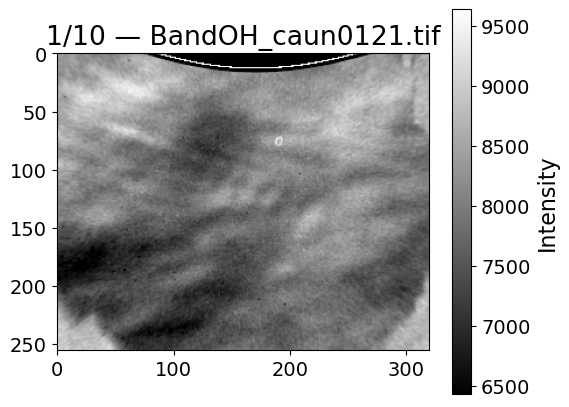

In [3]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import tifffile as tiff
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# --------------------
# User settings
# --------------------
FOLDER = r"C:\Users\domin\juwavelet\examples\Waves For Anh\Sep14th527"
FACTOR = 0.5  # center ± FACTOR * sigma range


# Load all TIFFs into memory
files = sorted(glob.glob(os.path.join(FOLDER, "*.tif")))
if not files:
    raise FileNotFoundError("No TIFFs found in folder.")

frames = []
for f in files:
    img = tiff.imread(f)
    frames.append(img.astype(np.float32))

data = np.stack(frames, axis=0)   # shape: (N, ny, nx)

print(f"Loaded {len(files)} frames, shape = {data.shape}")

# Compute global stats for display
sample = data.ravel()
center = float(np.mean(sample))
sigma = float(np.std(sample))

vmin = center - FACTOR * sigma
vmax = center + FACTOR * sigma

print(f"center: {center:.2f}, sigma: {sigma:.2f}")
print(f"use range: [{vmin:.2f}, {vmax:.2f}]")

# --------------------
# Plot movie animation
# --------------------
fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(
    np.clip(data[0], vmin, vmax),
    cmap="gray",
    vmin=vmin, vmax=vmax,
    origin="upper"
)

title = ax.set_title(os.path.basename(files[0]))
plt.colorbar(im, ax=ax, label="Intensity")

def update(i):
    im.set_data(np.clip(data[i], vmin, vmax))
    title.set_text(f"{i+1}/{len(files)} — {os.path.basename(files[i])}")
    return im, title

anim = FuncAnimation(fig, update, frames=len(files), interval=400, blit=False)

HTML(anim.to_jshtml())


### Batch


In [9]:
# Full TIFF -> ROI -> background removal -> wavelet clusters (batch version)
#
# For each TIFF in TIFF_DIR, this script:
#   - Runs the same pipeline as before
#   - Saves the 9-panel overlay figure:
#         remaining_tapered_clean background + cluster reconstruction overlays
#
# Overlay figures are saved as:
#   OVERLAY_DIR / "<tiff_stem>_overlay_clusters.png"

from __future__ import annotations
from typing import Tuple, Optional

from pathlib import Path

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import tifffile as tiff

from scipy.ndimage import median_filter
from juwavelet import transform, utils, plot_utils

# --------------------------
# User params
# --------------------------

# Folder with input TIFFs
TIFF_DIR = r"C:\Users\domin\juwavelet\examples\Waves For Anh\Sep14th527"

# Optional explicit output folder for overlays
# If None, a subfolder "overlays" will be created inside TIFF_DIR
OVERLAY_DIR: Optional[str] = None

# ROI (pixel slices) for analysis. Set to None to use full image.
X_SLICE: Optional[slice] = slice(12, 308)
Y_SLICE: Optional[slice] = slice(18, 248)

# Single sigma factor: mean ± 0.5σ (computed once on full image)
SIGMA_FACTOR = 0.5

# Preprocessing / background
REMOVE_TREND = True         # include 2D plane in "background"
STANDARDIZE = True          # z-score like scaling before CWT
GAUSS_BLUR_SIGMA = 0        # 0 disables, else e.g. 0.8

# Edge taper on remaining field (before CWT)
APPLY_TAPER = True
TAPER_EDGE_PIXELS = 10      # width of tapered region near each edge (pixels)

# Despike options (applied after tapering, before CWT)
APPLY_DESPIKE = True
DESPIKE_SIZE = 5            # median window size (odd integer)
DESPIKE_K = 2.0             # threshold in local "sigma" units

# Wavelet params
S0 = 4
DJ = 1/8
JS = 50
JT = 18
ASPECT = 1

# Pixel spacing (km/pixel) for CWT (wavelengths will be in km)
DX = 0.623
DY = 0.623

# Cluster identification parameters
CLUSTER_MIN_AMP = 0.25      # min_amp for identify_cluster2d
CLUSTER_THR = 0.2           # thr for identify_cluster2d

# Plot controls
SHOW_FIGS = False           # True = show all plots for each file (slower)
SAVE_OVERLAY = True         # Save the overlay figure (this is the main batch product)

# --------------------------
# Plot style
# --------------------------
matplotlib.rcParams.update({
    "axes.labelsize": 16,
    "font.size": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "figure.figsize": [2 * 6.94, 2 * 4.29],
})


# --------------------------
# Helpers
# --------------------------
def load_tiff(
    path: str,
) -> np.ndarray:
    """Load single-frame 2D TIFF as float32 array."""
    img = tiff.imread(path)
    if img.ndim == 3 and img.shape[-1] == 1:
        img = img[..., 0]
    if img.ndim != 2:
        raise ValueError(f"Expected single-frame 2D TIFF; got shape {img.shape}")
    Z = np.asarray(img, dtype=np.float32)
    med = float(np.median(Z))
    Z = np.nan_to_num(Z, nan=med, posinf=med, neginf=med).astype(np.float32, copy=False)
    return Z


def fit_plane(Z: np.ndarray) -> np.ndarray:
    """
    Fit a 2D plane ax + by + c to Z (least squares) and return the plane.
    """
    ny, nx = Z.shape
    yy, xx = np.mgrid[0:ny, 0:nx]
    G = np.stack([xx.ravel(), yy.ravel(), np.ones(nx * ny)], axis=1)
    coeff, *_ = np.linalg.lstsq(G, Z.ravel(), rcond=None)
    plane = (coeff[0] * xx + coeff[1] * yy + coeff[2])
    return plane


def extract_first_fourier_bg(Z: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """
    From a 2D field Z, keep only the first Fourier components in x and y:

      - fundamental in x: kx = ±1, ky = 0
      - fundamental in y: ky = ±1, kx = 0

    Returns (background_from_fft, residual).
    """
    ny, nx = Z.shape
    F = np.fft.fft2(Z)
    F_bg = np.zeros_like(F, dtype=complex)

    # fundamental in x (along columns, ky = 0)
    if nx > 1:
        F_bg[0, 1] = F[0, 1]
        F_bg[0, -1] = F[0, -1]

    # fundamental in y (along rows, kx = 0)
    if ny > 1:
        F_bg[1, 0] = F[1, 0]
        F_bg[-1, 0] = F[-1, 0]

    bg = np.fft.ifft2(F_bg).real
    resid = Z - bg
    return bg, resid


def maybe_blur(Z: np.ndarray, sigma: float) -> np.ndarray:
    if sigma <= 0:
        return Z
    try:
        from scipy.ndimage import gaussian_filter
    except Exception:
        return Z
    return gaussian_filter(Z, sigma=float(sigma))


def _fmt(v: float) -> str:
    if not np.isfinite(v):
        return "∞"
    v = float(v)
    if abs(v) >= 1000 or abs(v) < 0.1:
        return f"{v:.2e}"
    elif abs(v) >= 100:
        return f"{v:.0f}"
    else:
        return f"{v:.1f}"


def despike_local_sigma(
    Z: np.ndarray,
    size: int = 3,
    k: float = 5.0,
) -> np.ndarray:
    """
    Replace pixels that deviate too much from a local median.

    Parameters
    ----------
    Z : 2D array
    size : int
        Window size for local median (3, 5, ...)
    k : float
        Threshold in units of local MAD (~sigma). Larger = more tolerant.

    Returns
    -------
    2D array, same shape as Z
    """
    Z = np.asarray(Z, float)
    med = median_filter(Z, size=size)
    mad = median_filter(np.abs(Z - med), size=size)
    mad = np.where(mad == 0, np.nan, mad)

    mask_spike = np.abs(Z - med) > k * mad

    Z_clean = Z.copy()
    Z_clean[mask_spike] = med[mask_spike]
    return Z_clean


# --------------------------
# Edge taper (Hanning near boundaries)
# --------------------------
def _hanning_edge_1d(n: int, edge: int) -> np.ndarray:
    """
    1D window that is ~0 at the very edges, ramps to 1 over `edge` pixels,
    and equals 1 in the interior. Hanning-like cosine ramp.
    """
    w = np.ones(n, dtype=float)
    if edge <= 0:
        return w
    edge = min(edge, n // 2)
    ramp = 0.5 * (1.0 - np.cos(np.linspace(0, np.pi, edge, endpoint=True)))
    w[:edge] = ramp
    w[-edge:] = ramp[::-1]
    return w


def apply_edge_hanning_taper(Z: np.ndarray, edge: int) -> np.ndarray:
    """
    Apply a separable 2D Hanning-like taper only near the edges:
      interior stays ~1
      transitions smoothly to 0 at the borders over `edge` pixels.
    """
    ny, nx = Z.shape
    if edge <= 0:
        return Z
    wx = _hanning_edge_1d(nx, edge)
    wy = _hanning_edge_1d(ny, edge)
    W = np.outer(wy, wx)   # shape (ny, nx)
    return Z * W


# --------------------------
# Single-file pipeline
# --------------------------
def run_pipeline_for_file(
    tiff_path: Path,
    overlay_dir: Path,
    show_figs: bool = False,
    save_overlay: bool = True,
) -> None:
    """
    Run the full pipeline on a single TIFF and optionally save the overlay figure.
    """
    print(f"\n=== Processing {tiff_path.name} ===")
    full = load_tiff(str(tiff_path))
    ny_full, nx_full = full.shape
    x_full = np.arange(nx_full, dtype=float)
    y_full = np.arange(ny_full, dtype=float)

    # Compute mean/std once on the full image, use ±0.5σ
    sample_full = full.ravel().astype(float)
    center = float(np.mean(sample_full))
    sigma = float(np.std(sample_full))
    k = SIGMA_FACTOR
    lo = center - k * sigma
    hi = center + k * sigma

    print(f"[Full] mean={center:.2f}, sigma={sigma:.2f}, clip=[{lo:.2f}, {hi:.2f}]")

    # Full preview (optional)
    if show_figs:
        preview = np.clip(full.astype(float), lo, hi)
        vals_full = preview.ravel()
        p5f, p50f, p95f = np.nanpercentile(vals_full, [5, 50, 95])
        print(f"[Full] Percentiles 5/50/95 (clipped): {p5f:.2f} / {p50f:.2f} / {p95f:.2f}")

        y_full_flip = y_full[::-1]

        fig_prev, ax_prev = plt.subplots()
        im_prev = ax_prev.pcolormesh(
            x_full,
            y_full_flip,
            preview,
            shading="auto",
            cmap="gray",
            vmin=lo,
            vmax=hi,
        )
        cb_prev = fig_prev.colorbar(im_prev, ax=ax_prev, fraction=0.046, pad=0.04)
        cb_prev.set_label("Intensity (a.u.)")
        ax_prev.set_xlabel("x (pixels)")
        ax_prev.set_ylabel("y (pixels)")
        ax_prev.set_title(f"{tiff_path.name}\nFull TIFF clipped to mean ± {k:.2f}σ")
        ax_prev.set_aspect("equal", adjustable="box")

        # ROI rectangle
        ysl_full = Y_SLICE if Y_SLICE is not None else slice(0, ny_full)
        xsl_full = X_SLICE if X_SLICE is not None else slice(0, nx_full)

        x0 = 0 if xsl_full.start is None else xsl_full.start
        x1 = nx_full if xsl_full.stop is None else xsl_full.stop
        y0 = 0 if ysl_full.start is None else ysl_full.start
        y1 = ny_full if ysl_full.stop is None else ysl_full.stop

        y0_disp = ny_full - y1
        y1_disp = ny_full - y0

        rect = patches.Rectangle(
            (x0, y0_disp),
            x1 - x0,
            y1_disp - y0_disp,
            linewidth=2,
            edgecolor="red",
            facecolor="none",
        )
        ax_prev.add_patch(rect)

        plt.tight_layout()
        plt.show()

    # ROI
    ysl = Y_SLICE if Y_SLICE is not None else slice(None, None)
    xsl = X_SLICE if X_SLICE is not None else slice(None, None)

    raw = full[ysl, xsl].astype(float)
    ny, nx = raw.shape
    x1d = np.arange(nx, dtype=float)
    y1d = np.arange(ny, dtype=float)[::-1]   # flipped for display

    print(f"[ROI] shape: {raw.shape}")

    # Clip ROI
    proc0 = np.clip(raw, lo, hi)

    # Background separation: plane + first Fourier
    if REMOVE_TREND:
        plane = fit_plane(proc0)
        detrended = proc0 - plane
    else:
        plane = np.zeros_like(proc0)
        detrended = proc0

    fourier_bg, _ = extract_first_fourier_bg(detrended)
    background = plane + fourier_bg
    remaining = proc0 - background

    # Edge taper
    if APPLY_TAPER:
        remaining_tapered = apply_edge_hanning_taper(remaining, TAPER_EDGE_PIXELS)
    else:
        remaining_tapered = remaining.copy()

    # Despike
    if APPLY_DESPIKE:
        remaining_tapered_clean = despike_local_sigma(
            remaining_tapered, size=DESPIKE_SIZE, k=DESPIKE_K
        )
    else:
        remaining_tapered_clean = remaining_tapered

    # Centered versions for plotting
    med = np.nanmedian(proc0)
    orig_c = proc0 - med
    bg_c = background - med
    rem_c = remaining
    rem_tapered_c = remaining_tapered_clean

    # Global color scale for 4-panel
    stacked = np.concatenate([
        orig_c.ravel(),
        bg_c.ravel(),
        rem_c.ravel(),
        rem_tapered_c.ravel(),
    ])
    p_low, p_high = np.nanpercentile(stacked, [1, 99])
    vmax = max(abs(p_low), abs(p_high))
    if vmax == 0 or not np.isfinite(vmax):
        vmax = 1.0
    vmin = -vmax

    # Optional background figure
    if show_figs:
        fig_bg, axs_bg = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)
        axes_bg_flat = axs_bg.flatten()

        imgs_bg = [
            (orig_c, "Original (median-sub, clipped)"),
            (bg_c, "Background (plane + first Fourier)"),
            (rem_c, "Remaining = original - background"),
            (rem_tapered_c, "Remaining with edge taper (spikes removed)"),
        ]

        im_bg = None
        for ax, (Z, title) in zip(axes_bg_flat, imgs_bg):
            im_bg = ax.pcolormesh(
                x1d,
                y1d,
                Z,
                shading="auto",
                cmap="RdBu_r",
                vmin=vmin,
                vmax=vmax,
            )
            ax.set_title(title)
            ax.set_xlabel("x (pixels)")
            ax.set_ylabel("y (pixels)")
            ax.set_aspect("equal")

        cbar_bg = fig_bg.colorbar(im_bg, ax=axs_bg, orientation="vertical",
                                  fraction=0.04, pad=0.02)
        cbar_bg.set_label("Intensity (a.u.)")

        plt.show()

    # Preprocess for CWT (standardize + blur)
    proc = remaining_tapered_clean.copy()
    if STANDARDIZE:
        m_proc = np.median(proc)
        proc = proc - m_proc
        s_proc = np.std(proc)
        proc = proc / s_proc if s_proc > 0 else proc
    proc = maybe_blur(proc, GAUSS_BLUR_SIGMA)

    # juwavelet expects (nx, ny); image is (ny, nx)
    wave_xy = proc.T

    cwt = transform.decompose2d(
        wave_xy, dx=DX, dy=DY, s0=S0, dj=DJ, js=JS, jt=JT, aspect=ASPECT
    )

    # Identify clusters
    amps, idxs, iwave = utils.identify_cluster2d(
        cwt, min_amp=CLUSTER_MIN_AMP, thr=CLUSTER_THR
    )

    decomposition = cwt["decomposition"]
    orig_decomp = decomposition.copy()

    # Optional overview CWT plot + FOV spectrum
    if show_figs:
        cmap_cwt = matplotlib.cm.turbo
        norm_cwt = matplotlib.colors.BoundaryNorm(
            np.exp(np.linspace(np.log(0.05), np.log(1.0), 10)), cmap_cwt.N
        )
        fig_cwt, _ = utils.plot_decomposition2d(cwt, redux_s=4, redux_t=2,
                                                cmap=cmap_cwt, norm=norm_cwt)
        plt.show(fig_cwt)

        plot_utils.plot_fov_wavelet_spectrum(cwt, stat="max")

    # Background for overlays: tapered remaining field (centered, spikes removed), grayscale
    bg_tapered_centered = remaining_tapered_clean - np.median(remaining_tapered_clean)
    bg_low, bg_high = np.nanpercentile(bg_tapered_centered, [2, 98])
    bg_vmax = max(abs(bg_low), abs(bg_high))
    if not np.isfinite(bg_vmax) or bg_vmax == 0:
        bg_vmax = 1.0
    bg_vmin = -bg_vmax

    # ---------- Figure: overlays (this is what we save) ----------
    fig2, axs2 = plt.subplots(3, 3, figsize=(12, 10))
    axes2_flat = axs2.flatten()

    n_clusters = len(amps) if amps is not None else 0
    print(f"[Clusters] n_clusters = {n_clusters}")

    if n_clusters == 0:
        for ax in axes2_flat:
            ax.set_title("no clusters found")
            ax.axis("off")
    else:
        order = np.argsort(amps)[::-1]
        n_show = min(9, n_clusters)
        biggest = order[:n_show]

        cl_vmin, cl_vmax = -0.6, 0.6

        for ax, kcl in zip(axes2_flat, biggest):
            # Background: tapered remaining field (centered, spikes removed), grayscale
            ax.pcolormesh(
                x1d,
                y1d,
                bg_tapered_centered,
                shading="auto",
                cmap="gray",
                vmin=bg_vmin,
                vmax=bg_vmax,
            )

            # Reconstruct cluster
            decomposition[:] = orig_decomp
            decomposition[iwave != kcl] = 0
            rec = transform.reconstruct2d(cwt)  # (nx, ny)
            rec_centered = rec.T - np.median(rec)

            udx = idxs[kcl]
            s_idx = int(udx[0])
            t_idx = int(udx[1])

            lamx = cwt["wavelength_x"][s_idx, t_idx]
            lamy = cwt["wavelength_y"][s_idx, t_idx]

            inv2 = 0.0
            if np.isfinite(lamx) and lamx != 0:
                inv2 += (1.0 / lamx) ** 2
            if np.isfinite(lamy) and lamy != 0:
                inv2 += (1.0 / lamy) ** 2
            lam = np.inf if inv2 == 0 else 1.0 / np.sqrt(inv2)

            ax.pcolormesh(
                x1d,
                y1d,
                rec_centered,
                shading="auto",
                cmap="RdBu_r",
                vmin=cl_vmin,
                vmax=cl_vmax,
                alpha=0.6,
            )

            ax.set_title(rf"$\lambda$={_fmt(lam)}")
            ax.set_aspect("equal", adjustable="box")

            print(
                f"[Overlay] Cluster {kcl}: amp={amps[kcl]:.3f}, "
                f"lamx={lamx:.2f}, lamy={lamy:.2f}, "
                f"lam={'inf' if not np.isfinite(lam) else f'{lam:.2f}'}"
            )

        # Hide unused axes
        for ax in axes2_flat[n_show:]:
            ax.set_title("no cluster")
            ax.axis("off")

    for ax in axs2[2, :]:
        ax.set_xlabel("x (pixels)")
    for ax in axs2[:, 0]:
        ax.set_ylabel("y (pixels)")

    number_box = {
        "boxstyle": "square",
        "lw": 0.67,
        "facecolor": "white",
        "edgecolor": "black",
    }
    for i, ax in enumerate(axes2_flat, start=1):
        ax.text(
            0.12,
            0.15,
            str(i),
            transform=ax.transAxes,
            bbox=number_box,
            va="top",
            ha="right",
        )

    fig2.tight_layout()

    # Save overlay figure
    if save_overlay:
        overlay_dir.mkdir(parents=True, exist_ok=True)
        out_path = overlay_dir / f"{tiff_path.stem}_overlay_clusters.png"
        fig2.savefig(out_path, dpi=200)
        print(f"[Save] Overlay saved to: {out_path}")

    if show_figs:
        plt.show(fig2)
    else:
        plt.close(fig2)


# --------------------------
# Batch driver
# --------------------------
def run_batch():
    tiff_dir = Path(TIFF_DIR)
    overlay_dir = Path(OVERLAY_DIR) if OVERLAY_DIR is not None else tiff_dir / "overlays"

    files = sorted(list(tiff_dir.glob("*.tif")) + list(tiff_dir.glob("*.tiff")))
    if not files:
        print(f"No TIFF files found in {tiff_dir}")
        return

    print(f"Found {len(files)} TIFF files in {tiff_dir}")
    print(f"Overlay output directory: {overlay_dir}")

    for tiff_path in files:
        run_pipeline_for_file(
            tiff_path=tiff_path,
            overlay_dir=overlay_dir,
            show_figs=SHOW_FIGS,
            save_overlay=SAVE_OVERLAY,
        )


# --------------------------
# Run
# --------------------------
if __name__ == "__main__":
    run_batch()


Found 10 TIFF files in C:\Users\domin\juwavelet\examples\Waves For Anh\Sep14th527
Overlay output directory: C:\Users\domin\juwavelet\examples\Waves For Anh\Sep14th527\overlays

=== Processing BandOH_caun0121.tif ===
[Full] mean=7913.33, sigma=3217.16, clip=[6304.75, 9521.91]
[ROI] shape: (230, 296)
------------
cluster= 0
amplitude= 0.3965708109216384 idx= (np.int64(15), np.int64(7), np.int64(99), np.int64(164))
selected elements: 117722
------------
cluster= 1
amplitude= 0.3963176971882907 idx= (np.int64(20), np.int64(7), np.int64(237), np.int64(111))
selected elements: 124481
------------
cluster= 2
amplitude= 0.3959749323833172 idx= (np.int64(12), np.int64(11), np.int64(53), np.int64(46))
selected elements: 47038
------------
cluster= 3
amplitude= 0.3765293935415222 idx= (np.int64(27), np.int64(7), np.int64(66), np.int64(148))
selected elements: 1123743
------------
cluster= 4
amplitude= 0.3709046165220733 idx= (np.int64(30), np.int64(4), np.int64(122), np.int64(145))
selected eleme

### Apply the filters before indentifying the clusters

In [7]:
# Full TIFF -> ROI -> background removal -> wavelet clusters (batch version)
#
# For each TIFF in TIFF_DIR, this script:
#   - Runs the same pipeline as before
#   - Applies band-pass and angle filters to the wavelet decomposition
#       *before* cluster identification
#   - Identifies clusters on the filtered decomposition
#   - Saves a single-panel overlay figure:
#         remaining_tapered_clean background + strongest cluster reconstruction overlay
#
# Overlay figures are saved as:
#   OVERLAY_DIR / "<tiff_stem>_overlay_clusters.png"

from __future__ import annotations
from typing import Tuple, Optional

from pathlib import Path

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import tifffile as tiff

from scipy.ndimage import median_filter
from juwavelet import transform, utils, plot_utils

# --------------------------
# User params
# --------------------------

# Folder with input TIFFs
TIFF_DIR = r"C:\Users\domin\juwavelet\examples\Waves For Anh\Sep14th527"

# Optional explicit output folder for overlays
# If None, a subfolder "overlays" will be created inside TIFF_DIR
OVERLAY_DIR: Optional[str] = None

# ROI (pixel slices) for analysis. Set to None to use full image.
X_SLICE: Optional[slice] = slice(12, 308)
Y_SLICE: Optional[slice] = slice(18, 248)

# Single sigma factor: mean ± 0.5σ (computed once on full image)
SIGMA_FACTOR = 0.5

# Preprocessing / background
REMOVE_TREND = True         # include 2D plane in "background"
STANDARDIZE = True          # z-score like scaling before CWT
GAUSS_BLUR_SIGMA = 0        # 0 disables, else e.g. 0.8

# Edge taper on remaining field (before CWT)
APPLY_TAPER = True
TAPER_EDGE_PIXELS = 10      # width of tapered region near each edge (pixels)

# Despike options (applied after tapering, before CWT)
APPLY_DESPIKE = True
DESPIKE_SIZE = 5            # median window size (odd integer)
DESPIKE_K = 2.0             # threshold in local "sigma" units

# Wavelet params
S0 = 4
DJ = 1/8
JS = 50
JT = 18
ASPECT = 1

# Pixel spacing (km/pixel) for CWT (wavelengths will be in km)
DX = 0.623
DY = 0.623

# Cluster identification parameters
CLUSTER_MIN_AMP = 0.25      # min_amp for identify_cluster2d
CLUSTER_THR = 0.1           # thr for identify_cluster2d

# Band-pass filter on effective wavelength λ (km)
# λ is computed from λx, λy via: 1/λ² = 1/λx² + 1/λy²
ENABLE_BANDPASS = True     # set True to enable band-pass
BANDPASS_LMIN_KM = 8.0     # lower bound in km
BANDPASS_LMAX_KM = 16.0    # upper bound in km

# Angle filter on wave-vector direction (degrees)
# Angle is defined from kx, ky via atan2(ky, kx), then wrapped to [0, 180)
ENABLE_ANGLE_FILTER = True   # set True to enable angle filter
ANGLE_MIN_DEG = 90.0           # lower bound in degrees
ANGLE_MAX_DEG = 130.0         # upper bound in degrees

# Plot controls
SHOW_FIGS = False           # True = show all plots for each file (slower)
SAVE_OVERLAY = True         # Save the overlay figure (this is the main batch product)

# --------------------------
# Plot style
# --------------------------
matplotlib.rcParams.update({
    "axes.labelsize": 16,
    "font.size": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "figure.figsize": [2 * 6.94, 2 * 4.29],
})


# --------------------------
# Helpers
# --------------------------
def load_tiff(
    path: str,
) -> np.ndarray:
    """Load single-frame 2D TIFF as float32 array."""
    img = tiff.imread(path)
    if img.ndim == 3 and img.shape[-1] == 1:
        img = img[..., 0]
    if img.ndim != 2:
        raise ValueError(f"Expected single-frame 2D TIFF; got shape {img.shape}")
    Z = np.asarray(img, dtype=np.float32)
    med = float(np.median(Z))
    Z = np.nan_to_num(Z, nan=med, posinf=med, neginf=med).astype(np.float32, copy=False)
    return Z


def fit_plane(Z: np.ndarray) -> np.ndarray:
    """
    Fit a 2D plane ax + by + c to Z (least squares) and return the plane.
    """
    ny, nx = Z.shape
    yy, xx = np.mgrid[0:ny, 0:nx]
    G = np.stack([xx.ravel(), yy.ravel(), np.ones(nx * ny)], axis=1)
    coeff, *_ = np.linalg.lstsq(G, Z.ravel(), rcond=None)
    plane = (coeff[0] * xx + coeff[1] * yy + coeff[2])
    return plane


def extract_first_fourier_bg(Z: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """
    From a 2D field Z, keep only the first Fourier components in x and y:

      - fundamental in x: kx = ±1, ky = 0
      - fundamental in y: ky = ±1, kx = 0

    Returns (background_from_fft, residual).
    """
    ny, nx = Z.shape
    F = np.fft.fft2(Z)
    F_bg = np.zeros_like(F, dtype=complex)

    # fundamental in x (along columns, ky = 0)
    if nx > 1:
        F_bg[0, 1] = F[0, 1]
        F_bg[0, -1] = F[0, -1]

    # fundamental in y (along rows, kx = 0)
    if ny > 1:
        F_bg[1, 0] = F[1, 0]
        F_bg[-1, 0] = F[-1, 0]

    bg = np.fft.ifft2(F_bg).real
    resid = Z - bg
    return bg, resid


def maybe_blur(Z: np.ndarray, sigma: float) -> np.ndarray:
    if sigma <= 0:
        return Z
    try:
        from scipy.ndimage import gaussian_filter
    except Exception:
        return Z
    return gaussian_filter(Z, sigma=float(sigma))


def _fmt(v: float) -> str:
    if not np.isfinite(v):
        return "∞"
    v = float(v)
    if abs(v) >= 1000 or abs(v) < 0.1:
        return f"{v:.2e}"
    elif abs(v) >= 100:
        return f"{v:.0f}"
    else:
        return f"{v:.1f}"


def despike_local_sigma(
    Z: np.ndarray,
    size: int = 3,
    k: float = 5.0,
) -> np.ndarray:
    """
    Replace pixels that deviate too much from a local median.

    Parameters
    ----------
    Z : 2D array
    size : int
        Window size for local median (3, 5, ...)
    k : float
        Threshold in units of local MAD (~sigma). Larger = more tolerant.

    Returns
    -------
    2D array, same shape as Z
    """
    Z = np.asarray(Z, float)
    med = median_filter(Z, size=size)
    mad = median_filter(np.abs(Z - med), size=size)
    mad = np.where(mad == 0, np.nan, mad)

    mask_spike = np.abs(Z - med) > k * mad

    Z_clean = Z.copy()
    Z_clean[mask_spike] = med[mask_spike]
    return Z_clean


# --------------------------
# Edge taper (Hanning near boundaries)
# --------------------------
def _hanning_edge_1d(n: int, edge: int) -> np.ndarray:
    """
    1D window that is ~0 at the very edges, ramps to 1 over `edge` pixels,
    and equals 1 in the interior. Hanning-like cosine ramp.
    """
    w = np.ones(n, dtype=float)
    if edge <= 0:
        return w
    edge = min(edge, n // 2)
    ramp = 0.5 * (1.0 - np.cos(np.linspace(0, np.pi, edge, endpoint=True)))
    w[:edge] = ramp
    w[-edge:] = ramp[::-1]
    return w


def apply_edge_hanning_taper(Z: np.ndarray, edge: int) -> np.ndarray:
    """
    Apply a separable 2D Hanning-like taper only near the edges:
      interior stays ~1
      transitions smoothly to 0 at the borders over `edge` pixels.
    """
    ny, nx = Z.shape
    if edge <= 0:
        return Z
    wx = _hanning_edge_1d(nx, edge)
    wy = _hanning_edge_1d(ny, edge)
    W = np.outer(wy, wx)   # shape (ny, nx)
    return Z * W


# --------------------------
# Helpers for λ and angle
# --------------------------
def compute_lambda_theta_fields(cwt: dict) -> Tuple[np.ndarray, np.ndarray]:
    """
    Compute effective wavelength λ (km) and angle θ (deg) for all (s, t).

    λ is from λx, λy via: 1/λ² = 1/λx² + 1/λy²
    θ is from kx, ky via atan2(ky, kx), wrapped to [0, 180).
    """
    lamx = np.asarray(cwt["wavelength_x"], float)
    lamy = np.asarray(cwt["wavelength_y"], float)

    # Effective wavelength
    with np.errstate(divide="ignore", invalid="ignore"):
        inv_lamx2 = np.where(np.isfinite(lamx) & (lamx != 0.0), 1.0 / (lamx**2), 0.0)
        inv_lamy2 = np.where(np.isfinite(lamy) & (lamy != 0.0), 1.0 / (lamy**2), 0.0)
        inv2 = inv_lamx2 + inv_lamy2
        lam_eff = np.where(inv2 > 0, 1.0 / np.sqrt(inv2), np.inf)

        # Wavevector components
        kx = np.where(np.isfinite(lamx) & (lamx != 0.0), 1.0 / lamx, 0.0)
        ky = np.where(np.isfinite(lamy) & (lamy != 0.0), 1.0 / lamy, 0.0)

        theta_deg = np.degrees(np.arctan2(ky, kx))
        theta_deg = np.mod(theta_deg, 180.0)  # [0, 180)

    return lam_eff, theta_deg


def compute_cluster_lambda_and_angle(
    cwt: dict,
    idx_s: int,
    idx_t: int,
) -> Tuple[float, float]:
    """
    Convenience for a single cluster (for logging/title).
    """
    lam_eff, theta_deg = compute_lambda_theta_fields(cwt)
    lam = float(lam_eff[idx_s, idx_t])
    theta = float(theta_deg[idx_s, idx_t])
    return lam, theta


# --------------------------
# Single-file pipeline
# --------------------------
def run_pipeline_for_file(
    tiff_path: Path,
    overlay_dir: Path,
    show_figs: bool = False,
    save_overlay: bool = True,
) -> None:
    """
    Run the full pipeline on a single TIFF and optionally save the overlay figure.
    """
    print(f"\n=== Processing {tiff_path.name} ===")
    full = load_tiff(str(tiff_path))
    ny_full, nx_full = full.shape
    x_full = np.arange(nx_full, dtype=float)
    y_full = np.arange(ny_full, dtype=float)

    # Compute mean/std once on the full image, use ±0.5σ
    sample_full = full.ravel().astype(float)
    center = float(np.mean(sample_full))
    sigma = float(np.std(sample_full))
    k = SIGMA_FACTOR
    lo = center - k * sigma
    hi = center + k * sigma

    print(f"[Full] mean={center:.2f}, sigma={sigma:.2f}, clip=[{lo:.2f}, {hi:.2f}]")

    # Full preview (optional)
    if show_figs:
        preview = np.clip(full.astype(float), lo, hi)
        vals_full = preview.ravel()
        p5f, p50f, p95f = np.nanpercentile(vals_full, [5, 50, 95])
        print(f"[Full] Percentiles 5/50/95 (clipped): {p5f:.2f} / {p50f:.2f} / {p95f:.2f}")

        y_full_flip = y_full[::-1]

        fig_prev, ax_prev = plt.subplots()
        im_prev = ax_prev.pcolormesh(
            x_full,
            y_full_flip,
            preview,
            shading="auto",
            cmap="gray",
            vmin=lo,
            vmax=hi,
        )
        cb_prev = fig_prev.colorbar(im_prev, ax=ax_prev, fraction=0.046, pad=0.04)
        cb_prev.set_label("Intensity (a.u.)")
        ax_prev.set_xlabel("x (pixels)")
        ax_prev.set_ylabel("y (pixels)")
        ax_prev.set_title(f"{tiff_path.name}\nFull TIFF clipped to mean ± {k:.2f}σ")
        ax_prev.set_aspect("equal", adjustable="box")

        # ROI rectangle
        ysl_full = Y_SLICE if Y_SLICE is not None else slice(0, ny_full)
        xsl_full = X_SLICE if X_SLICE is not None else slice(0, nx_full)

        x0 = 0 if xsl_full.start is None else xsl_full.start
        x1 = nx_full if xsl_full.stop is None else xsl_full.stop
        y0 = 0 if ysl_full.start is None else ysl_full.start
        y1 = ny_full if ysl_full.stop is None else ysl_full.stop

        y0_disp = ny_full - y1
        y1_disp = ny_full - y0

        rect = patches.Rectangle(
            (x0, y0_disp),
            x1 - x0,
            y1_disp - y0_disp,
            linewidth=2,
            edgecolor="red",
            facecolor="none",
        )
        ax_prev.add_patch(rect)

        plt.tight_layout()
        plt.show()

    # ROI
    ysl = Y_SLICE if Y_SLICE is not None else slice(None, None)
    xsl = X_SLICE if X_SLICE is not None else slice(None, None)

    raw = full[ysl, xsl].astype(float)
    ny, nx = raw.shape
    x1d = np.arange(nx, dtype=float)
    y1d = np.arange(ny, dtype=float)[::-1]   # flipped for display

    print(f"[ROI] shape: {raw.shape}")

    # Clip ROI
    proc0 = np.clip(raw, lo, hi)

    # Background separation: plane + first Fourier
    if REMOVE_TREND:
        plane = fit_plane(proc0)
        detrended = proc0 - plane
    else:
        plane = np.zeros_like(proc0)
        detrended = proc0

    fourier_bg, _ = extract_first_fourier_bg(detrended)
    background = plane + fourier_bg
    remaining = proc0 - background

    # Edge taper
    if APPLY_TAPER:
        remaining_tapered = apply_edge_hanning_taper(remaining, TAPER_EDGE_PIXELS)
    else:
        remaining_tapered = remaining.copy()

    # Despike
    if APPLY_DESPIKE:
        remaining_tapered_clean = despike_local_sigma(
            remaining_tapered, size=DESPIKE_SIZE, k=DESPIKE_K
        )
    else:
        remaining_tapered_clean = remaining_tapered

    # Centered versions for plotting
    med = np.nanmedian(proc0)
    orig_c = proc0 - med
    bg_c = background - med
    rem_c = remaining
    rem_tapered_c = remaining_tapered_clean

    # Global color scale for 4-panel
    stacked = np.concatenate([
        orig_c.ravel(),
        bg_c.ravel(),
        rem_c.ravel(),
        rem_tapered_c.ravel(),
    ])
    p_low, p_high = np.nanpercentile(stacked, [1, 99])
    vmax = max(abs(p_low), abs(p_high))
    if vmax == 0 or not np.isfinite(vmax):
        vmax = 1.0
    vmin = -vmax

    # Optional background figure
    if show_figs:
        fig_bg, axs_bg = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)
        axes_bg_flat = axs_bg.flatten()

        imgs_bg = [
            (orig_c, "Original (median-sub, clipped)"),
            (bg_c, "Background (plane + first Fourier)"),
            (rem_c, "Remaining = original - background"),
            (rem_tapered_c, "Remaining with edge taper (spikes removed)"),
        ]

        im_bg = None
        for ax, (Z, title) in zip(axes_bg_flat, imgs_bg):
            im_bg = ax.pcolormesh(
                x1d,
                y1d,
                Z,
                shading="auto",
                cmap="RdBu_r",
                vmin=vmin,
                vmax=vmax,
            )
            ax.set_title(title)
            ax.set_xlabel("x (pixels)")
            ax.set_ylabel("y (pixels)")
            ax.set_aspect("equal")

        cbar_bg = fig_bg.colorbar(im_bg, ax=axs_bg, orientation="vertical",
                                  fraction=0.04, pad=0.02)
        cbar_bg.set_label("Intensity (a.u.)")

        plt.show()

    # Preprocess for CWT (standardize + blur)
    proc = remaining_tapered_clean.copy()
    if STANDARDIZE:
        m_proc = np.median(proc)
        proc = proc - m_proc
        s_proc = np.std(proc)
        proc = proc / s_proc if s_proc > 0 else proc
    proc = maybe_blur(proc, GAUSS_BLUR_SIGMA)

    # juwavelet expects (nx, ny); image is (ny, nx)
    wave_xy = proc.T

    cwt = transform.decompose2d(
        wave_xy, dx=DX, dy=DY, s0=S0, dj=DJ, js=JS, jt=JT, aspect=ASPECT
    )

    # --------------------------
    # Apply band-pass & angle filters to decomposition BEFORE clustering
    # --------------------------
    decomposition = cwt["decomposition"]
    ns, nt, nx_cwt, ny_cwt = decomposition.shape

    lam_eff, theta_deg = compute_lambda_theta_fields(cwt)

    mask_keep = np.ones_like(lam_eff, dtype=bool)

    if ENABLE_BANDPASS:
        mask_band = (
            np.isfinite(lam_eff)
            & (lam_eff >= BANDPASS_LMIN_KM)
            & (lam_eff <= BANDPASS_LMAX_KM)
        )
        mask_keep &= mask_band

    if ENABLE_ANGLE_FILTER:
        mask_angle = (
            np.isfinite(theta_deg)
            & (theta_deg >= ANGLE_MIN_DEG)
            & (theta_deg <= ANGLE_MAX_DEG)
        )
        mask_keep &= mask_angle

    n_total_modes = lam_eff.size
    n_keep_modes = int(mask_keep.sum())
    print(f"[Filter] Modes kept: {n_keep_modes}/{n_total_modes}")

    # Broadcast mask over spatial dims and zero-out disallowed modes
    mask4 = mask_keep[:, :, None, None].astype(decomposition.dtype)
    decomposition *= mask4

    # --------------------------
    # Identify clusters on filtered decomposition
    # --------------------------
    amps, idxs, iwave = utils.identify_cluster2d(
        cwt, min_amp=CLUSTER_MIN_AMP, thr=CLUSTER_THR
    )

    orig_decomp = decomposition.copy()

    # Optional overview CWT plot + FOV spectrum
    if show_figs and n_keep_modes > 0:
        cmap_cwt = matplotlib.cm.turbo
        norm_cwt = matplotlib.colors.BoundaryNorm(
            np.exp(np.linspace(np.log(0.05), np.log(1.0), 10)), cmap_cwt.N
        )
        fig_cwt, _ = utils.plot_decomposition2d(cwt, redux_s=4, redux_t=2,
                                                cmap=cmap_cwt, norm=norm_cwt)
        plt.show(fig_cwt)

        plot_utils.plot_fov_wavelet_spectrum(cwt, stat="max")

    # Background for overlays: tapered remaining field (centered, spikes removed), grayscale
    bg_tapered_centered = remaining_tapered_clean - np.median(remaining_tapered_clean)
    bg_low, bg_high = np.nanpercentile(bg_tapered_centered, [2, 98])
    bg_vmax = max(abs(bg_low), abs(bg_high))
    if not np.isfinite(bg_vmax) or bg_vmax == 0:
        bg_vmax = 1.0
    bg_vmin = -bg_vmax

    # ---------- Choose the strongest cluster (if any) ----------
    n_clusters = len(amps) if amps is not None else 0
    print(f"[Clusters] n_clusters (after filters) = {n_clusters}")

    if n_clusters > 0:
        kcl = int(np.argmax(amps))
        udx = idxs[kcl]
        s_idx = int(udx[0])
        t_idx = int(udx[1])
        lam_best, theta_best = compute_cluster_lambda_and_angle(cwt, s_idx, t_idx)
        print(
            f"[Best cluster] k={kcl}, amp={amps[kcl]:.3f}, "
            f"lam={_fmt(lam_best)}, theta={theta_best:.1f}°"
        )
        best_cluster_info = (kcl, lam_best, theta_best)
    else:
        best_cluster_info = None

    # ---------- Figure: background + overlay pair (this is what we save) ----------
    # Left: background only
    # Right: background + strongest cluster overlay
    fig2, (ax_bg, ax_ov) = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)

    if best_cluster_info is None:
        print("[Clusters] No cluster found after filters; nothing to overlay.")

        # Left: background only
        im_bg = ax_bg.pcolormesh(
            x1d,
            y1d,
            bg_tapered_centered,
            shading="auto",
            cmap="gray",
            vmin=bg_vmin,
            vmax=bg_vmax,
        )
        ax_bg.set_title("Background (tapered, despiked)")
        ax_bg.set_xlabel("x (pixels)")
        ax_bg.set_ylabel("y (pixels)")
        ax_bg.set_aspect("equal", adjustable="box")

        # Right: message only
        ax_ov.text(
            0.5,
            0.5,
            "no cluster after filters",
            transform=ax_ov.transAxes,
            ha="center",
            va="center",
        )
        ax_ov.set_axis_off()

    else:
        kcl, lam_best, theta_best = best_cluster_info

        # Left: background only
        ax_bg.pcolormesh(
            x1d,
            y1d,
            bg_tapered_centered,
            shading="auto",
            cmap="gray",
            vmin=bg_vmin,
            vmax=bg_vmax,
        )
        ax_bg.set_title("Background (tapered, despiked)")
        ax_bg.set_xlabel("x (pixels)")
        ax_bg.set_ylabel("y (pixels)")
        ax_bg.set_aspect("equal", adjustable="box")

        # Right: background + overlay
        ax_ov.pcolormesh(
            x1d,
            y1d,
            bg_tapered_centered,
            shading="auto",
            cmap="gray",
            vmin=bg_vmin,
            vmax=bg_vmax,
        )

        # Reconstruct selected cluster
        decomposition[:] = orig_decomp
        decomposition[iwave != kcl] = 0
        rec = transform.reconstruct2d(cwt)  # (nx, ny)
        rec_centered = rec.T - np.median(rec)

        # Overlay cluster reconstruction
        cl_vmin, cl_vmax = -0.6, 0.6
        ax_ov.pcolormesh(
            x1d,
            y1d,
            rec_centered,
            shading="auto",
            cmap="RdBu_r",
            vmin=cl_vmin,
            vmax=cl_vmax,
            alpha=0.6,
        )

        title_str = rf"$\lambda$={_fmt(lam_best)}, $\theta$={theta_best:.1f}°"
        ax_ov.set_title(title_str)
        ax_ov.set_aspect("equal", adjustable="box")
        ax_ov.set_xlabel("x (pixels)")
        ax_ov.set_ylabel("y (pixels)")

        print(
            f"[Overlay] Cluster {kcl}: amp={amps[kcl]:.3f}, "
            f"lam={_fmt(lam_best)}, theta={theta_best:.1f}°"
        )

        # Numbered box (always "1" now) on the overlay panel
        number_box = {
            "boxstyle": "square",
            "lw": 0.67,
            "facecolor": "white",
            "edgecolor": "black",
        }
        ax_ov.text(
            0.12,
            0.15,
            "1",
            transform=ax_ov.transAxes,
            bbox=number_box,
            va="top",
            ha="right",
        )

    fig2.tight_layout()

    # Save overlay figure
    if save_overlay:
        overlay_dir.mkdir(parents=True, exist_ok=True)
        out_path = overlay_dir / f"{tiff_path.stem}_overlay_clusters.png"
        fig2.savefig(out_path, dpi=200)
        print(f"[Save] Overlay saved to: {out_path}")

    if show_figs:
        plt.show(fig2)
    else:
        plt.close(fig2)


# --------------------------
# Batch driver
# --------------------------
def run_batch():
    tiff_dir = Path(TIFF_DIR)
    overlay_dir = Path(OVERLAY_DIR) if OVERLAY_DIR is not None else tiff_dir / "overlays"

    files = sorted(list(tiff_dir.glob("*.tif")) + list(tiff_dir.glob("*.tiff")))
    if not files:
        print(f"No TIFF files found in {tiff_dir}")
        return

    print(f"Found {len(files)} TIFF files in {tiff_dir}")
    print(f"Overlay output directory: {overlay_dir}")

    for tiff_path in files:
        run_pipeline_for_file(
            tiff_path=tiff_path,
            overlay_dir=overlay_dir,
            show_figs=SHOW_FIGS,
            save_overlay=SAVE_OVERLAY,
        )


# --------------------------
# Run
# --------------------------
if __name__ == "__main__":
    run_batch()


Found 10 TIFF files in C:\Users\domin\juwavelet\examples\Waves For Anh\Sep14th527
Overlay output directory: C:\Users\domin\juwavelet\examples\Waves For Anh\Sep14th527\overlays

=== Processing BandOH_caun0121.tif ===
[Full] mean=7913.33, sigma=3217.16, clip=[6304.75, 9521.91]
[ROI] shape: (230, 296)
[Filter] Modes kept: 43/900
------------
cluster= 0
amplitude= 0.3959749323833172 idx= (np.int64(12), np.int64(11), np.int64(53), np.int64(46))
selected elements: 294701
------------
cluster= 1
amplitude= 0.33960699791471843 idx= (np.int64(13), np.int64(10), np.int64(181), np.int64(55))
selected elements: 96826
------------
cluster= 2
amplitude= 0.30808044805377516 idx= (np.int64(16), np.int64(9), np.int64(178), np.int64(61))
selected elements: 31064
------------
cluster= 3
amplitude= 0.26382035495072403 idx= (np.int64(15), np.int64(9), np.int64(84), np.int64(212))
selected elements: 14393
[Clusters] n_clusters (after filters) = 4
[Best cluster] k=0, amp=0.396, lam=11.3, theta=110.0°
[Overla